<a href="https://colab.research.google.com/github/Ejemuta/Capstone-Project-Assignment/blob/master/Simplified_THM_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# INSTALLS
# ============================================================

!pip -q install pyvista pyamg tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 6.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import pandas as pd

from tqdm import tqdm
from scipy.ndimage import gaussian_filter

In [ ]:
# ============================================================
# GRID
# ============================================================

Nx, Ny, Nz = 64, 64, 32

dx = 20.0  # meters
dy = 20.0
dz = 10.0

nt = 250
dt = 0.05

shape = (Nx, Ny, Nz)

print("Cells:", Nx*Ny*Nz)

Cells: 131072


In [ ]:
# ============================================================
# RANDOM GEOLOGY
# ============================================================

np.random.seed(42)

# permeability field (mD)
logk = gaussian_filter(
    np.random.normal(size=shape),
    sigma=6
)

k_field = 10**(logk + 1)

# porosity
phi_field = 0.12 + 0.08 * (
    gaussian_filter(np.random.rand(*shape), sigma=4)
)

# Young modulus (GPa)
E_field = 10 + 30 * gaussian_filter(
    np.random.rand(*shape),
    sigma=5
)

# thermal expansion
alpha_T = 3e-5

# Biot coefficient
alpha_biot = 0.8

In [ ]:
# ============================================================
# INITIAL STRESSES
# ============================================================

sigma_H = 65e6
sigma_h = 45e6
sigma_v = 55e6

tau_background = 18e6

In [ ]:
# ============================================================
# FAULT GEOMETRY
# ============================================================

X, Y, Z = np.meshgrid(
    np.arange(Nx),
    np.arange(Ny),
    np.arange(Nz),
    indexing='ij'
)

# random fault plane
a = 1
b = -1
c = 0.3
d = -20

distance = np.abs(a*X + b*Y + c*Z + d)

fault_mask = distance < 2

print("Fault cells:", fault_mask.sum())

Fault cells: 6034


In [ ]:
# ============================================================
# INJECTION WELL
# ============================================================

wx, wy, wz = Nx//2, Ny//2, Nz//2

inj_rate = 15.0
inj_temp = -20.0  # cooling effect

pressure = np.zeros(shape)
temperature = np.zeros(shape)

In [ ]:
# ============================================================
# PRESSURE DIFFUSION
# ============================================================

def laplacian(field):

    return (
        np.roll(field,1,0)
        + np.roll(field,-1,0)
        + np.roll(field,1,1)
        + np.roll(field,-1,1)
        + np.roll(field,1,2)
        + np.roll(field,-1,2)
        - 6*field
    )

# diffusivity
D = 0.18

pressure_history = []
slip_history = []

In [ ]:
# ============================================================
# MAIN SIMULATION
# ============================================================

mu_fault = 0.6

for t in tqdm(range(nt)):

    # ------------------------------------
    # Pressure diffusion
    # ------------------------------------

    pressure += D * laplacian(pressure) * dt

    # injection source
    pressure[wx, wy, wz] += inj_rate

    # ------------------------------------
    # Temperature diffusion
    # ------------------------------------

    temperature += 0.12 * laplacian(temperature) * dt

    temperature[wx, wy, wz] += inj_temp

    # ------------------------------------
    # Thermo-poroelastic stress
    # ------------------------------------

    delta_sigma_p = alpha_biot * pressure

    delta_sigma_T = (
        E_field * 1e9 * alpha_T * temperature
    )

    sigma_eff = (
        sigma_h
        - delta_sigma_p
        - delta_sigma_T
    )

    # ------------------------------------
    # Coulomb Failure Stress
    # ------------------------------------

    cfs = (
        tau_background
        - mu_fault * sigma_eff
    )

    slip = (cfs > 0).astype(np.int8)

    pressure_history.append(
        pressure.copy()
    )

    slip_history.append(
        slip.copy()
    )

100%|██████████| 250/250 [00:03<00:00, 66.16it/s]


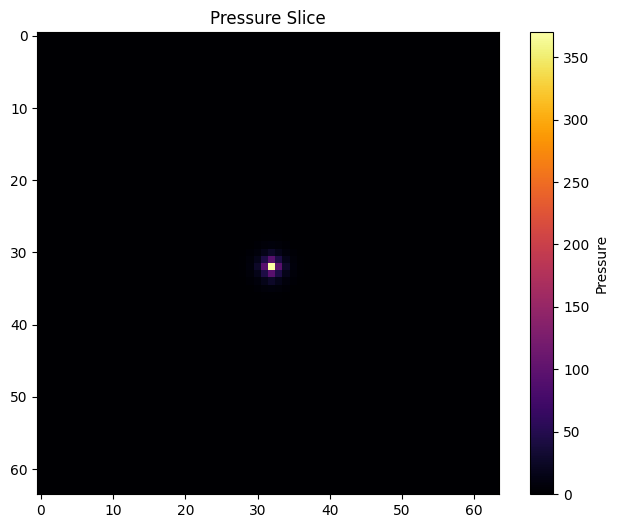

In [ ]:
# ============================================================
# PRESSURE SLICE
# ============================================================

midz = Nz // 2

plt.figure(figsize=(8,6))

plt.imshow(
    pressure[:,:,midz],
    cmap='inferno'
)

plt.colorbar(label='Pressure')
plt.title("Pressure Slice")
plt.show()

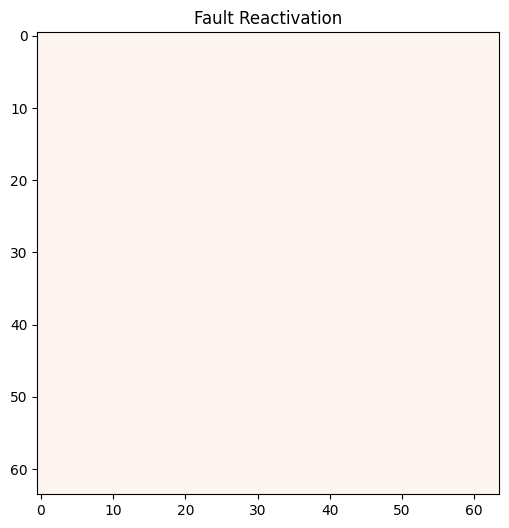

In [ ]:
# ============================================================
# SLIP VISUALIZATION
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(
    slip[:,:,midz],
    cmap='Reds'
)

plt.title("Fault Reactivation")
plt.show()

/tmp/ipykernel_2093/3972603302.py:25: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  p.show()


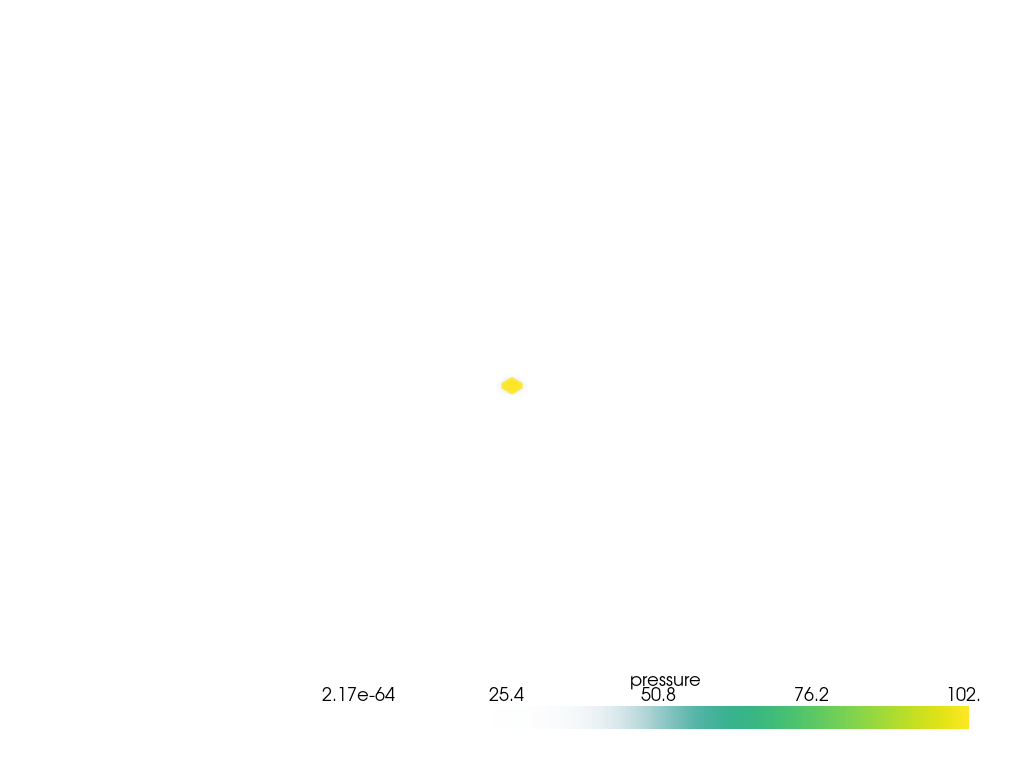

In [ ]:
# ============================================================
# 3D VISUALIZATION
# ============================================================

grid = pv.ImageData()

grid.dimensions = np.array(
    pressure.shape
) + 1

grid.spacing = (dx, dy, dz)

grid.cell_data["pressure"] = pressure.flatten(order="F")
grid.cell_data["slip"] = slip.flatten(order="F")

p = pv.Plotter()

p.add_volume(
    grid,
    scalars="pressure",
    opacity='sigmoid',
    cmap='viridis'
)

p.show()

In [ ]:
# ============================================================
# ML DATASET
# ============================================================

dataset = []

sample = {

    "pressure": pressure.astype(np.float32),

    "temperature": temperature.astype(np.float32),

    "permeability": k_field.astype(np.float32),

    "porosity": phi_field.astype(np.float32),

    "slip": slip.astype(np.int8)

}

dataset.append(sample)

print("Dataset size:", len(dataset))

Dataset size: 1
